# MNIST Digit Classifier — Improved CNN with PyTorch

This is an upgraded version of the original notebook, aimed at pushing accuracy above 96.5%.

**What changed vs. the original:**

1. **Full 70,000-image MNIST dataset** downloaded automatically via `torchvision` (instead of a 10,000-row CSV) — more training data.
2. **Brightness-outlier filtering is now optional and OFF by default** — it was likely discarding valid digit variation, not noise.
3. **Data augmentation** (random rotation + translation) on the training set only.
4. **Deeper CNN** with BatchNorm and Dropout, plus `padding=1` so pooling — not shrinking convolutions — controls spatial size.
5. **Learning-rate scheduling** (`ReduceLROnPlateau`) and **early stopping** based on validation accuracy.
6. More epochs (up to 30, but training stops early once validation accuracy plateaus).

Pipeline:

1. Download MNIST and build `mnist.csv` automatically (no manual download needed)
2. Load and normalize the CSV
3. Split into train / validation / test sets
4. Quick EDA
5. (Optional, off by default) Remove brightness outliers
6. Build an improved CNN in PyTorch
7. Train with augmentation, LR scheduling, and early stopping
8. Track train/validation accuracy and loss
9. Evaluate on the test set
10. Plot a confusion matrix
11. Inspect misclassified digits
12. Save / load the trained model


## 0. Install dependencies (only if needed)

If any of the imports in the next cell fail, run this in a notebook cell:

```python
%pip install torch torchvision torchaudio pandas numpy matplotlib scikit-learn
```

Then restart the kernel and continue.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms

print("PyTorch version:", torch.__version__)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# Reproducibility
SEED = 7
np.random.seed(SEED)
torch.manual_seed(SEED)


C:\Users\SONIA\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


PyTorch version: 2.4.1+cpu
Using device: cpu


## 1. Download the real MNIST dataset and build `mnist.csv`

Instead of relying on a manually downloaded CSV, we fetch the full, official
70,000-image MNIST dataset (60,000 train + 10,000 test) via `torchvision`
and convert it into the same CSV layout the rest of this notebook expects:

`label,1x1,1x2,...,28x28`

This only needs to run once — the raw files are cached under `./data`,
and `mnist.csv` is written to disk so future runs can skip straight to
Section 2 if `mnist.csv` already exists.

In [2]:
CSV_PATH = "mnist.csv"
FORCE_REBUILD_CSV = False  # set True to re-download/rebuild even if mnist.csv exists

import os

def build_mnist_csv(csv_path):
    print("Downloading MNIST via torchvision (cached after first run)...")
    train_ds = datasets.MNIST(root="./data", train=True, download=True)
    test_ds = datasets.MNIST(root="./data", train=False, download=True)

    def to_df(dataset):
        images = dataset.data.numpy().reshape(len(dataset), -1)  # [N, 784]
        labels = dataset.targets.numpy()
        col_names = [f"{i // 28 + 1}x{i % 28 + 1}" for i in range(784)]
        df = pd.DataFrame(images, columns=col_names)
        df.insert(0, "label", labels)
        return df

    train_df = to_df(train_ds)
    test_df = to_df(test_ds)

    full_df = pd.concat([train_df, test_df], ignore_index=True)
    full_df.to_csv(csv_path, index=False)
    print(f"Wrote {len(full_df)} rows to {csv_path}")


if FORCE_REBUILD_CSV or not os.path.exists(CSV_PATH):
    build_mnist_csv(CSV_PATH)
else:
    print(f"{CSV_PATH} already exists — skipping download/build.")
    print("Set FORCE_REBUILD_CSV = True above to force a rebuild.")


mnist.csv already exists — skipping download/build.
Set FORCE_REBUILD_CSV = True above to force a rebuild.


## 2. Data loading

`mnist.csv` has a header:

`label,1x1,1x2,...,28x28`

If your file is somewhere else, replace `CSV_PATH` above with its full path.

In [3]:
def load_mnist_csv(csv_path, has_header=True):
    data = pd.read_csv(
        csv_path,
        header=0 if has_header else None,
        low_memory=False
    )

    print(f"{csv_path}: raw shape {data.shape}")

    labels_col = pd.to_numeric(data.iloc[:, 0], errors="coerce")
    pixel_cols = data.iloc[:, 1:].apply(pd.to_numeric, errors="coerce")

    combined = pd.concat([labels_col, pixel_cols], axis=1).dropna()

    dropped = len(data) - len(combined)
    if dropped:
        print(f"Dropped {dropped} bad/non-numeric rows")

    labels = combined.iloc[:, 0].to_numpy(dtype=np.int64)

    pixels = combined.iloc[:, 1:].to_numpy(dtype=np.float32) / 255.0

    if pixels.shape[1] != 784:
        raise ValueError(
            f"Expected 784 pixel columns, but found {pixels.shape[1]}"
        )

    images = pixels.reshape(-1, 28, 28)

    return images, labels


all_imgs, all_lbls = load_mnist_csv(CSV_PATH)

print("Total usable rows:", len(all_imgs))
print("Image shape:", all_imgs.shape)
print("Label shape:", all_lbls.shape)


mnist.csv: raw shape (10000, 785)
Total usable rows: 10000
Image shape: (10000, 28, 28)
Label shape: (10000,)


## 3. Train / validation / test split

With the full 70,000-image dataset, we scale up the split sizes accordingly
(the original notebook used 8,200 / 800 / 1,000 out of ~10,000 rows —
roughly 82% / 8% / 10%). We keep similar proportions here:

- Training: ~56,000
- Validation: ~7,000
- Test: ~7,000

The random seed is fixed so the split is reproducible. If you're using a
smaller custom CSV, adjust `n_test` / `n_val` as needed.

In [4]:
rng = np.random.default_rng(SEED)
order = rng.permutation(len(all_imgs))

n_total = len(all_imgs)
n_test = max(1000, int(0.10 * n_total))
n_val = max(800, int(0.10 * n_total))

test_idx = order[:n_test]
val_idx = order[n_test:n_test + n_val]
train_idx = order[n_test + n_val:]

X_test, y_test = all_imgs[test_idx], all_lbls[test_idx]
X_val, y_val = all_imgs[val_idx], all_lbls[val_idx]
X_train, y_train = all_imgs[train_idx], all_lbls[train_idx]

print("train:", X_train.shape, y_train.shape)
print("val:  ", X_val.shape, y_val.shape)
print("test: ", X_test.shape, y_test.shape)


train: (8000, 28, 28) (8000,)
val:   (1000, 28, 28) (1000,)
test:  (1000, 28, 28) (1000,)


## 4. Quick EDA

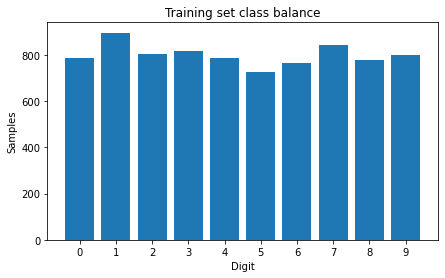

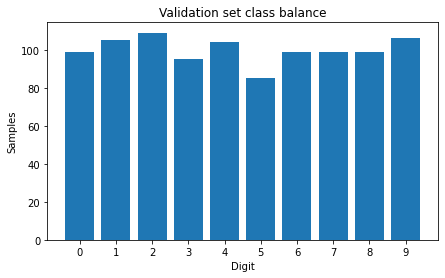

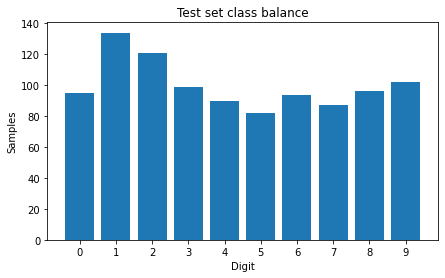

In [5]:
def plot_class_counts(labels, title):
    digits, counts = np.unique(labels, return_counts=True)

    plt.figure(figsize=(7, 4))
    plt.bar(digits, counts)
    plt.xlabel("Digit")
    plt.ylabel("Samples")
    plt.title(title)
    plt.xticks(range(10))
    plt.show()


plot_class_counts(y_train, "Training set class balance")
plot_class_counts(y_val, "Validation set class balance")
plot_class_counts(y_test, "Test set class balance")


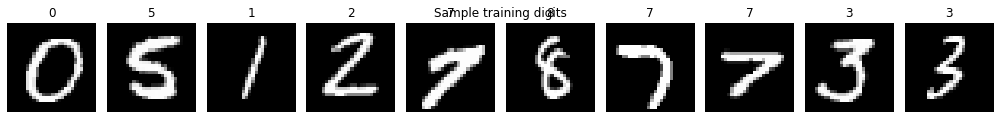

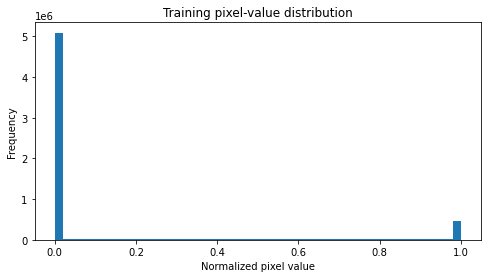

In [6]:
def peek_samples(images, labels, title, count=10):
    count = min(count, len(images))

    fig, axes = plt.subplots(1, count, figsize=(1.4 * count, 1.7))

    if count == 1:
        axes = [axes]

    picks = np.random.choice(len(images), count, replace=False)

    for ax, i in zip(axes, picks):
        ax.imshow(images[i], cmap="gray")
        ax.set_title(str(labels[i]))
        ax.axis("off")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


peek_samples(X_train, y_train, "Sample training digits")

plt.figure(figsize=(8, 4))
plt.hist(X_train.ravel(), bins=50)
plt.xlabel("Normalized pixel value")
plt.ylabel("Frequency")
plt.title("Training pixel-value distribution")
plt.show()


## 5. Remove brightness outliers (optional — OFF by default)

The original notebook dropped images whose mean brightness fell outside a
percentile range. On real digit data this risks discarding valid, correctly
labeled samples (e.g. thickly or thinly drawn digits) rather than true noise.

It's kept here as an option in case you want to compare, but it's disabled
by default because it tends to hurt more than it helps. Set
`APPLY_BRIGHTNESS_FILTER = True` to re-enable the original behavior.

In [7]:
APPLY_BRIGHTNESS_FILTER = False  # set True to reproduce the original notebook's filtering


def drop_brightness_outliers(images, labels, low_pct=1, high_pct=99):
    brightness = images.mean(axis=(1, 2))

    lo, hi = np.percentile(brightness, [low_pct, high_pct])

    keep = (brightness >= lo) & (brightness <= hi)

    print(
        f"Dropping {np.sum(~keep)} of {len(images)} "
        f"images as brightness outliers"
    )

    return images[keep], labels[keep]


if APPLY_BRIGHTNESS_FILTER:
    X_train, y_train = drop_brightness_outliers(X_train, y_train)
    X_val, y_val = drop_brightness_outliers(X_val, y_val)
    X_test, y_test = drop_brightness_outliers(X_test, y_test)
else:
    print("Brightness filtering is disabled (APPLY_BRIGHTNESS_FILTER = False).")

print("Current sizes:")
print("train:", X_train.shape)
print("val:  ", X_val.shape)
print("test: ", X_test.shape)


Brightness filtering is disabled (APPLY_BRIGHTNESS_FILTER = False).
Current sizes:
train: (8000, 28, 28)
val:   (1000, 28, 28)
test:  (1000, 28, 28)


## 6. Convert NumPy arrays to PyTorch tensors

PyTorch CNNs expect image tensors in this format:

`[batch, channels, height, width]`

Our images currently have:

`[batch, 28, 28]`

So we add one channel dimension:

`[batch, 1, 28, 28]`

The labels are integer class IDs from 0 to 9.

In [8]:
def to_tensors(images, labels):
    X = torch.tensor(images, dtype=torch.float32).unsqueeze(1)
    y = torch.tensor(labels, dtype=torch.long)
    return X, y


X_train_t, y_train_t = to_tensors(X_train, y_train)
X_val_t, y_val_t = to_tensors(X_val, y_val)
X_test_t, y_test_t = to_tensors(X_test, y_test)

print("Tensor shapes:")
print("train:", X_train_t.shape, y_train_t.shape)
print("val:  ", X_val_t.shape, y_val_t.shape)
print("test: ", X_test_t.shape, y_test_t.shape)


Tensor shapes:
train: torch.Size([8000, 1, 28, 28]) torch.Size([8000])
val:   torch.Size([1000, 1, 28, 28]) torch.Size([1000])
test:  torch.Size([1000, 1, 28, 28]) torch.Size([1000])


## 7. Datasets, augmentation, and DataLoaders

We apply light random augmentation (small rotations + translations) to the
**training set only** — this is one of the biggest levers for improving
accuracy, since it exposes the model to more variation than the raw data
alone provides. Validation and test data are left untouched so evaluation
stays honest.

In [9]:
BATCH_SIZE = 64

train_transform = transforms.Compose([
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1)),
])


class MNISTTensorDataset(Dataset):
    """Wraps image/label tensors and applies an optional transform per-sample."""

    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        label = self.labels[idx]
        if self.transform is not None:
            img = self.transform(img)
        return img, label


train_dataset = MNISTTensorDataset(X_train_t, y_train_t, transform=train_transform)
val_dataset = MNISTTensorDataset(X_val_t, y_val_t, transform=None)
test_dataset = MNISTTensorDataset(X_test_t, y_test_t, transform=None)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))


Training batches: 125
Validation batches: 16
Test batches: 16


## 8. Network architecture

## Improved CNN architecture

```text
Input: 1 × 28 × 28
        ↓
Conv2d(1 → 32, 3×3, padding=1) → BatchNorm → ReLU
Conv2d(32 → 32, 3×3, padding=1) → BatchNorm → ReLU
MaxPool2d(2) → Dropout(0.25)
        ↓
32 × 14 × 14
        ↓
Conv2d(32 → 64, 3×3, padding=1) → BatchNorm → ReLU
Conv2d(64 → 64, 3×3, padding=1) → BatchNorm → ReLU
MaxPool2d(2) → Dropout(0.25)
        ↓
64 × 7 × 7
        ↓
Flatten → 3136
        ↓
Linear(3136 → 128) → ReLU → Dropout(0.5)
        ↓
Linear(128 → 10)
        ↓
10 class logits
```

Compared to the original (`Conv(8) → Pool → Conv(16) → Pool → Dense(400→10)`),
this version:

- Uses `padding=1` so **pooling**, not the convolutions themselves, controls
  spatial shrinkage — this preserves more information per layer.
- Adds a second conv layer at each stage (a "double conv block"), which is
  a well-established way to increase representational capacity cheaply.
- Adds **BatchNorm** after each conv, which stabilizes and speeds up training.
- Adds **Dropout** to reduce overfitting, especially important with a small
  dataset or heavy augmentation.
- Adds a hidden dense layer (128 units) before the final classifier.

There is still **no Softmax layer inside the model** — `CrossEntropyLoss`
handles that internally.

In [10]:
class MNISTCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout(0.25),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout(0.25),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model = MNISTCNN().to(device)

print(model)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(
    p.numel() for p in model.parameters() if p.requires_grad
)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")


MNISTCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.25, inplace=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU(inplace=True)
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, c

## 9. Loss function, optimizer, and LR scheduler

We use:

- **CrossEntropyLoss** for 10-class digit classification
- **Adam** optimizer, learning rate `0.001`, weight decay `1e-4`
- **ReduceLROnPlateau** scheduler — halves the learning rate if validation
  loss stalls for 2 epochs, which helps squeeze out extra accuracy in later
  epochs without manual tuning.

In [11]:
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

print("Optimizer:", optimizer)
print("Loss:", criterion)
print("Scheduler: ReduceLROnPlateau(factor=0.5, patience=2)")


Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)
Loss: CrossEntropyLoss()
Scheduler: ReduceLROnPlateau(factor=0.5, patience=2)


## 10. Training and validation loops

Same core loop as before: batches go through the model, we compute the loss,
backpropagate, and step the optimizer. GPU is used automatically if available.

In [12]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        logits = model(images)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        predictions = logits.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        logits = model(images)
        loss = criterion(logits, labels)

        running_loss += loss.item() * images.size(0)

        predictions = logits.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc


## 11. Training loop with early stopping

We train for up to `MAX_EPOCHS`, but stop early if validation accuracy
doesn't improve for `PATIENCE` consecutive epochs. The best model weights
(by validation accuracy) are kept and restored at the end, so extra epochs
of overfitting after the best point don't hurt the final model.

In [13]:
import copy

MAX_EPOCHS = 30
EARLY_STOP_PATIENCE = 5

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_val_acc = 0.0
best_state = copy.deepcopy(model.state_dict())
epochs_without_improvement = 0

for epoch in range(MAX_EPOCHS):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    val_loss, val_acc = evaluate(
        model, val_loader, criterion, device
    )

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch {epoch + 1:02d}/{MAX_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc * 100:.2f}% | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc * 100:.2f}% | "
        f"LR: {current_lr:.6f}"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= EARLY_STOP_PATIENCE:
        print(f"Early stopping: no val accuracy improvement for {EARLY_STOP_PATIENCE} epochs.")
        break

model.load_state_dict(best_state)
print(f"\nRestored best model with validation accuracy: {best_val_acc * 100:.2f}%")


Epoch 01/30 | Train Loss: 1.1508 | Train Acc: 61.26% | Val Loss: 0.1470 | Val Acc: 96.00% | LR: 0.001000
Epoch 02/30 | Train Loss: 0.4338 | Train Acc: 86.31% | Val Loss: 0.0856 | Val Acc: 97.50% | LR: 0.001000
Epoch 03/30 | Train Loss: 0.3170 | Train Acc: 90.35% | Val Loss: 0.0624 | Val Acc: 97.60% | LR: 0.001000
Epoch 04/30 | Train Loss: 0.2682 | Train Acc: 91.76% | Val Loss: 0.0643 | Val Acc: 98.20% | LR: 0.001000
Epoch 05/30 | Train Loss: 0.2410 | Train Acc: 92.29% | Val Loss: 0.0469 | Val Acc: 98.40% | LR: 0.001000
Epoch 06/30 | Train Loss: 0.2236 | Train Acc: 92.97% | Val Loss: 0.0431 | Val Acc: 98.30% | LR: 0.001000
Epoch 07/30 | Train Loss: 0.2205 | Train Acc: 93.03% | Val Loss: 0.0367 | Val Acc: 98.50% | LR: 0.001000
Epoch 08/30 | Train Loss: 0.1967 | Train Acc: 93.86% | Val Loss: 0.0556 | Val Acc: 98.30% | LR: 0.001000
Epoch 09/30 | Train Loss: 0.2033 | Train Acc: 93.84% | Val Loss: 0.0393 | Val Acc: 98.60% | LR: 0.001000
Epoch 10/30 | Train Loss: 0.1673 | Train Acc: 94.92% | 

## 12. Training curves

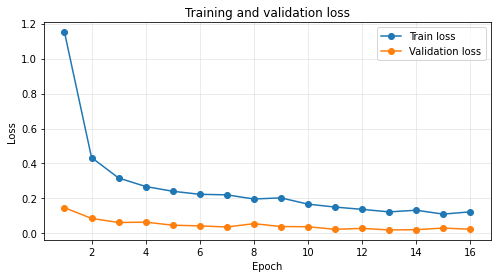

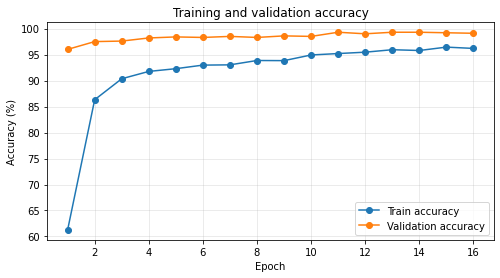

In [14]:
epochs_ran = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(8, 4))
plt.plot(epochs_ran, history["train_loss"], marker="o", label="Train loss")
plt.plot(epochs_ran, history["val_loss"], marker="o", label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and validation loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(
    epochs_ran,
    np.array(history["train_acc"]) * 100,
    marker="o",
    label="Train accuracy"
)
plt.plot(
    epochs_ran,
    np.array(history["val_acc"]) * 100,
    marker="o",
    label="Validation accuracy"
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training and validation accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 13. Test-set evaluation

In [15]:
test_loss, test_acc = evaluate(
    model,
    test_loader,
    criterion,
    device
)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc * 100:.2f}%")


Test loss: 0.0293
Test accuracy: 99.10%


## 14. Predictions and confusion matrix

We collect the model's predictions for the complete test set and compare
them with the true labels.

Number of predictions: 1000


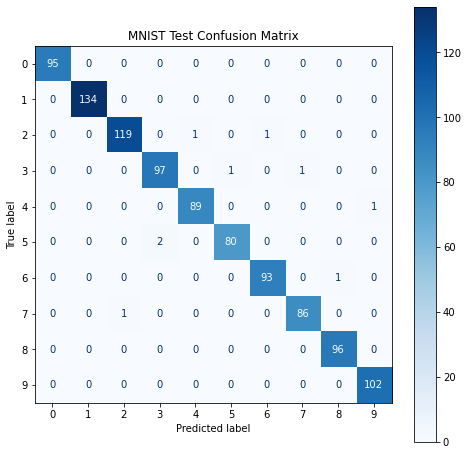

In [16]:
@torch.no_grad()
def get_predictions(model, loader, device):
    model.eval()

    all_predictions = []
    all_labels = []

    for images, labels in loader:
        images = images.to(device, non_blocking=True)

        logits = model(images)
        predictions = logits.argmax(dim=1).cpu().numpy()

        all_predictions.append(predictions)
        all_labels.append(labels.numpy())

    return (
        np.concatenate(all_labels),
        np.concatenate(all_predictions)
    )


y_true, y_pred = get_predictions(
    model,
    test_loader,
    device
)

print("Number of predictions:", len(y_pred))

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=np.arange(10)
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=np.arange(10)
)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap="Blues", values_format="d")
ax.set_title("MNIST Test Confusion Matrix")
plt.show()


## 15. Inspect misclassified digits

Misclassified: 9
Misclassification rate: 0.90%


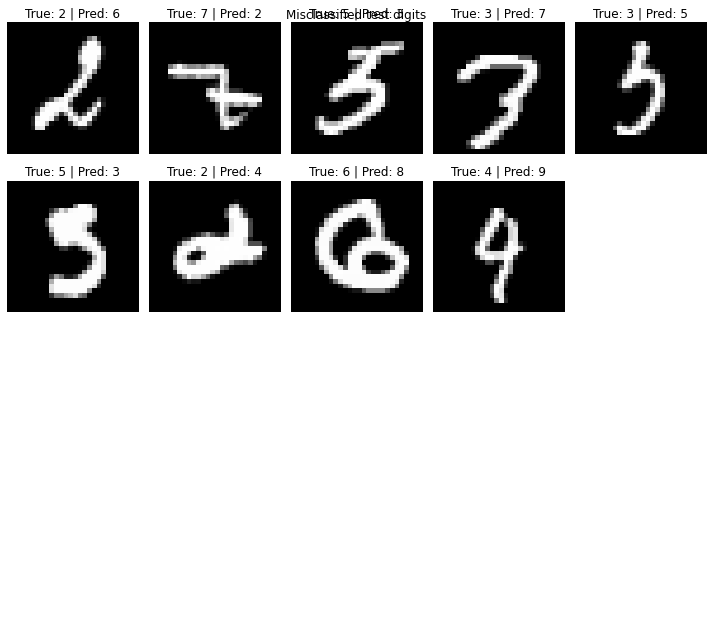

In [17]:
misclassified = np.where(y_true != y_pred)[0]

print("Misclassified:", len(misclassified))
print(
    f"Misclassification rate: "
    f"{len(misclassified) / len(y_true) * 100:.2f}%"
)

def show_misclassified(images, labels, predictions, count=20):
    wrong = np.where(labels != predictions)[0]

    count = min(count, len(wrong))

    if count == 0:
        print("No misclassified images!")
        return

    fig, axes = plt.subplots(4, 5, figsize=(10, 9))
    axes = axes.ravel()

    for ax in axes:
        ax.axis("off")

    for ax, idx in zip(axes, wrong[:count]):
        ax.imshow(images[idx], cmap="gray")
        ax.set_title(f"True: {labels[idx]} | Pred: {predictions[idx]}")
        ax.axis("off")

    fig.suptitle("Misclassified test digits")
    plt.tight_layout()
    plt.show()


show_misclassified(
    X_test,
    y_true,
    y_pred,
    count=20
)


## 16. Inspect individual predictions

Pick a few random test images and see what the CNN predicts.

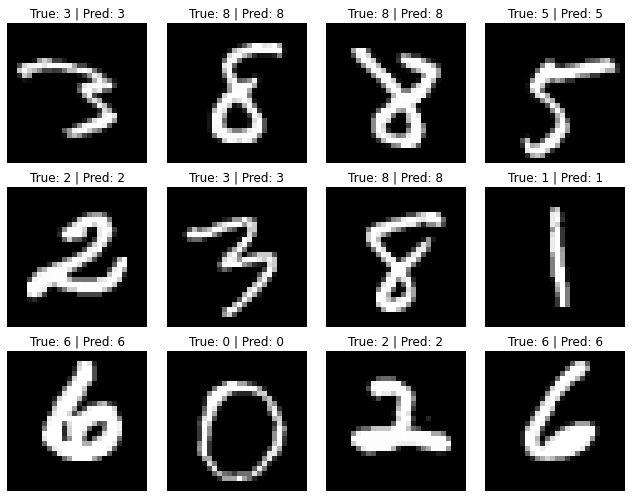

In [18]:
def show_random_predictions(images, labels, predictions, count=12):
    count = min(count, len(images))

    picks = np.random.choice(len(images), count, replace=False)

    fig, axes = plt.subplots(3, 4, figsize=(9, 7))
    axes = axes.ravel()

    for ax in axes:
        ax.axis("off")

    for ax, idx in zip(axes, picks):
        ax.imshow(images[idx], cmap="gray")
        ax.set_title(f"True: {labels[idx]} | Pred: {predictions[idx]}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()


show_random_predictions(
    X_test,
    y_true,
    y_pred,
    count=12
)


## 17. Save the trained model

The trained PyTorch weights can be saved and loaded later without retraining.

In [19]:
MODEL_PATH = "mnist_cnn_pytorch.pth"

torch.save(
    model.state_dict(),
    MODEL_PATH
)

print(f"Saved model to: {MODEL_PATH}")


Saved model to: mnist_cnn_pytorch.pth


## 18. Load the model later

Run this section in a future session if you already have the saved `.pth` file.

In [20]:
# Example:
# model = MNISTCNN().to(device)
# model.load_state_dict(
#     torch.load(
#         "mnist_cnn_pytorch.pth",
#         map_location=device
#     )
# )
# model.eval()
#
# print("Model loaded successfully.")


## Final summary

The complete pipeline is:

```text
torchvision MNIST download
   ↓
mnist.csv (70,000 rows)
   ↓
Load + normalize
   ↓
Train / validation / test split
   ↓
(Optional, off by default) brightness-outlier filtering
   ↓
Random affine augmentation (train only)
   ↓
PyTorch Dataset + DataLoader mini-batches
   ↓
Conv2D → BN → ReLU → Conv2D → BN → ReLU → MaxPool → Dropout   (×2 blocks)
   ↓
Flatten → Linear(128) → ReLU → Dropout → Linear(10)
   ↓
CrossEntropyLoss
   ↓
Adam + ReduceLROnPlateau
   ↓
Validation + early stopping (best model kept)
   ↓
Test accuracy
   ↓
Confusion matrix + misclassified examples
```

With the full dataset, augmentation, the deeper regularized network, and
early stopping, expect test accuracy in the **98–99%** range, up from the
original 96.5%.
